# pixel classification and analysis on all images
a notebook to execute your classification and analysis

in Colab, we need to connect to a GPU

on the top right, go to change runtime type and select T4 GPU

In [ ]:
pip install readlif

In [ ]:
pip install scikit-image

In [ ]:
pip install matplotlib

In [ ]:
pip install openpyxl

It is normal that in colab, you might neeed to restart the session when you attempt to pip install apoc.... Simply confirm restart of the session and start from this executable cell (with apoc install), until it is executed....

In [ ]:
!pip install apoc --no-deps
!pip install "scikit-learn" "pyclesperanto-prototype" "pandas"
!pip install "numpy==2.4.4"

In [1]:
from matplotlib import pyplot as plt
import apoc
from skimage.io import imread, imsave
import numpy as np
from readlif.reader import LifFile
import tifffile # for reading TIFF metadata
from skimage.measure import label, regionprops # for quantifying objects in binary images
import pandas as pd # for data handling
import os
import tempfile
import zipfile
from pathlib import Path
from PIL import Image
import io
import openpyxl

This time we will be using a .zip file with all of our images and models...

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
    filename, raw_bytes = next(iter(uploaded.items()))
    zip_source = Path(filename)
    zip_source.write_bytes(raw_bytes)
    print(f"Path: {zip_source}")
    print(f"Exists: {zip_source.exists()}")          # save to current directory

except ImportError:
    import tkinter as tk
    from tkinter import filedialog
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    selected = filedialog.askopenfilename(
        title="Select a ZIP file",
        filetypes=[("ZIP archives", "*.zip")]
    )
    root.destroy()

    zip_source = Path(selected.replace("/", "\\"))
    print(f"Path: {zip_source}")
    print(f"Exists: {zip_source.exists()}")

Path: C:\Users\liebs\Downloads\images_analysis_2026.zip
Exists: True


For 2027, check whether mounting with gdrive works better, in a first attempt .zip upload directly in colab took more than 1 h, but a simple upload with gdrive was much faster... the following cell will simply give a code snipet that could be implemented for next year...

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

filename = 'images_analysis_2026.zip'  # was missing the 's'
zip_source = Path(f'/content/drive/MyDrive/Colab Notebooks/{filename}')

print(f"Path: {zip_source}")
print(f"Exists: {zip_source.exists()}")

Now we will be somewhat reusing code from before, but we will pack it in functions so that we can perform the entire analysis in the end. 

In [3]:
CHANNEL_ORDER = ["DAAO", "vGAT", "Cre", "Gphn"]


def _find_zip_member(zip_obj, suffix):
    # Match by tail so it works even if zip has a top-level folder.
    for name in zip_obj.namelist():
        if name.endswith(suffix) and not Path(name).name.startswith("._"):
            return name
    return None


def _load_segmenter(channel, zip_obj, temp_dir, project_root=None, cache=None):
    if cache is None:
        cache = {}

    if channel in cache:
        return cache[channel]

    rel_model = f"training_4_channels/{channel}/models/{channel}_object_model.cl"

    # 1) Prefer local filesystem model if available
    if project_root is not None:
        model_path = Path(project_root) / rel_model
        if model_path.exists():
            seg = apoc.ObjectSegmenter(opencl_filename=str(model_path))
            cache[channel] = seg
            return seg

    # 2) Else load model from zip into temp file
    member = _find_zip_member(zip_obj, rel_model)
    if member is None:
        raise FileNotFoundError(f"Model not found for channel {channel}: {rel_model}")

    model_tmp = Path(temp_dir) / f"{channel}_object_model.cl"
    if not model_tmp.exists():
        model_tmp.write_bytes(zip_obj.read(member))

    seg = apoc.ObjectSegmenter(opencl_filename=str(model_tmp))
    cache[channel] = seg
    return seg


def _to_numpy(array_like):
    """Convert APOC/OpenCL outputs to NumPy arrays for scikit-image."""
    if isinstance(array_like, np.ndarray):
        return array_like
    if hasattr(array_like, "get"):
        return array_like.get()
    return np.asarray(array_like)


def make_masks(channel, array, zip_obj, temp_dir, project_root=None, segmenter_cache=None):
    segmenter = _load_segmenter(
        channel=channel,
        zip_obj=zip_obj,
        temp_dir=temp_dir,
        project_root=project_root,
        cache=segmenter_cache,
    )
    labels = segmenter.predict(array)
    labels = _to_numpy(labels).astype(np.int32, copy=False)
    return labels


def _summarize_gphn(labels, intensity_image):
    props = regionprops(labels, intensity_image=intensity_image)
    n_objects = len(props)
    mean_area_px = float(np.mean([p.area for p in props])) if props else 0.0
    mean_intensity = float(np.mean([p.mean_intensity for p in props])) if props else 0.0
    return n_objects, mean_area_px, mean_intensity


def execute_zip_lif(zip_source, project_root=None):
    results = []
    segmenter_cache = {}

    with zipfile.ZipFile(zip_source, "r") as z, tempfile.TemporaryDirectory() as tmp:
        lif_members = sorted(
            name for name in z.namelist()
            if name.lower().endswith(".lif")
            and not name.startswith("__MACOSX/")
            and not Path(name).name.startswith("._")
        )

        print(f"Found {len(lif_members)} .lif file(s) in zip")

        for lif_member in lif_members:
            # LifFile needs a file path, so materialize only this .lif temporarily.
            lif_tmp = Path(tmp) / Path(lif_member).name
            lif_tmp.write_bytes(z.read(lif_member))

            lif = LifFile(str(lif_tmp))
            for img in lif.get_iter_image():
                channels_array = np.stack([np.array(ch) for ch in img.get_iter_c(t=0, z=0)])

                # LIF scales are in metadata; convert px^2 to um^2 using inverse x/y scales.
                x_scale, y_scale, z_scale, t_scale = img.scale
                if x_scale == 0 or y_scale == 0:
                    raise ValueError(f"Invalid scale metadata in image {img.name}: x_scale={x_scale}, y_scale={y_scale}")
                area_factor_um2 = (1.0 / x_scale) * (1.0 / y_scale)

                channel_images = {
                    channel: _to_numpy(channels_array[idx])
                    for idx, channel in enumerate(CHANNEL_ORDER)
                }

                labels_by_channel = {}
                for channel in CHANNEL_ORDER:
                    labels_by_channel[channel] = make_masks(
                        channel=channel,
                        array=channel_images[channel],
                        zip_obj=z,
                        temp_dir=tmp,
                        project_root=project_root,
                        segmenter_cache=segmenter_cache,
                    )

                gphn_labels = labels_by_channel["Gphn"]
                gphn_intensity_image = channel_images["Gphn"]
                vgat_labels = labels_by_channel["vGAT"]
                daao_labels = labels_by_channel["DAAO"]

                # All gephyrin clusters in this image
                n_gphn, mean_gphn_area_px, mean_gphn_intensity = _summarize_gphn(
                    gphn_labels, gphn_intensity_image
                )

                # Synaptic gephyrin: gephyrin objects overlapping vGAT-positive pixels
                overlap = (gphn_labels > 0) & (vgat_labels > 0)
                overlapping_labels = np.unique(gphn_labels[overlap])
                overlapping_labels = overlapping_labels[overlapping_labels != 0]

                gphn_vgat_positive = np.isin(gphn_labels, overlapping_labels)
                synaptic_gphn_labels = label(gphn_vgat_positive)

                n_syn_gphn, mean_syn_gphn_area_px, mean_syn_gphn_intensity = _summarize_gphn(
                    synaptic_gphn_labels, gphn_intensity_image
                )

                # Total segmented DAAO area converted to um^2
                total_daao_area_px = int(np.count_nonzero(daao_labels > 0))

                results.append({
                    "source_lif": Path(lif_member).name,
                    "image_name": img.name,
                    "#_gephyrin_clusters": int(n_gphn),
                    "#_synaptic_gephyrin_clusters": int(n_syn_gphn),
                    "mean_gephyrin_area_um2": mean_gphn_area_px * area_factor_um2,
                    "mean_synaptic_gephyrin_area_um2": mean_syn_gphn_area_px * area_factor_um2,
                    "mean_gephyrin_intensity": mean_gphn_intensity,
                    "mean_synaptic_gephyrin_intensity": mean_syn_gphn_intensity,
                    "total_DAAO_area_um2": total_daao_area_px * area_factor_um2,
                    "pixel_in_x": 1/x_scale,
                    "pixel_in_y": 1/y_scale,
                })

    return pd.DataFrame(results)

Finally we can run the entire analysis. 

In [4]:
# Build one-row-per-image results table
final_df = execute_zip_lif(zip_source, project_root=Path(".").resolve())

# Show the final per-image table (areas in um^2)
display(final_df)


Found 22 .lif file(s) in zip


C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\2665445325.py:69: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  mean_intensity = float(np.mean([p.mean_intensity for p in props])) if props else 0.0


,source_lif,image_name,#_gephyrin_clusters,#_synaptic_gephyrin_clusters,mean_gephyrin_area_um2,mean_synaptic_gephyrin_area_um2,mean_gephyrin_intensity,mean_synaptic_gephyrin_intensity,total_DAAO_area_um2,pixel_in_x,pixel_in_y
0,Gruppe1 WT + DMet High Density.lif,Image 1,144,66,1.409181,1.711056,8302.701247,8390.788297,1854.083576,0.180375,0.180375
1,Gruppe1 WT + DMet High Density.lif,Image 2,117,47,1.962679,2.525978,8884.198736,9184.781244,3283.062197,0.180375,0.180375
2,Gruppe1 WT + DMet High Density.lif,Image 3,145,63,1.590859,2.037323,8426.103543,8354.226187,1881.966244,0.180375,0.180375
3,Gruppe1 WT + DMet High Density.lif,Image 4,242,131,1.340262,1.705490,8414.915262,8312.351562,3784.364595,0.180375,0.180375
4,Gruppe1 WT + DMet High Density.lif,Image 5,117,54,1.467699,1.672550,8611.679866,9291.339836,3133.400267,0.180375,0.180375
...,...,...,...,...,...,...,...,...,...,...,...
106,Gruppe 5 Var3 - DMet High Density Backup.lif,Image 1,248,164,1.433254,1.623189,9026.552285,9221.519764,3778.703470,0.180375,0.180375
107,Gruppe 5 Var3 - DMet High Density Backup.lif,Image 2,318,194,1.160934,1.452512,8869.954739,8984.641453,2238.584597,0.180375,0.180375
108,Gruppe 5 Var3 - DMet High Density Backup.lif,Image 3,202,117,3.364655,4.946463,8973.643244,9245.966948,2551.508173,0.180375,0.180375
109,Gruppe 5 Var3 - DMet High Density Backup.lif,Image 4,215,105,1.119211,1.605070,8866.023643,8923.391459,3750.755731,0.180375,0.180375


We can quickly summarize by condition...

In [5]:
# Optional compact summary by source .lif
summary_by_lif = (
    final_df.groupby("source_lif", as_index=False)
    .agg(
        images=("image_name", "nunique"),
        mean_gephyrin_clusters=("#_gephyrin_clusters", "mean"),
        mean_synaptic_gephyrin_clusters=("#_synaptic_gephyrin_clusters", "mean"),
        mean_gephyrin_area_um2=("mean_gephyrin_area_um2", "mean"),
        mean_synaptic_gephyrin_area_um2=("mean_synaptic_gephyrin_area_um2", "mean"),
        mean_gephyrin_intensity=("mean_gephyrin_intensity", "mean"),
        mean_synaptic_gephyrin_intensity=("mean_synaptic_gephyrin_intensity", "mean"),
        mean_total_DAAO_area_um2=("total_DAAO_area_um2", "mean"),
    )
    .sort_values("source_lif")
    .reset_index(drop=True)
)

display(summary_by_lif)

,source_lif,images,mean_gephyrin_clusters,mean_synaptic_gephyrin_clusters,mean_gephyrin_area_um2,mean_synaptic_gephyrin_area_um2,mean_gephyrin_intensity,mean_synaptic_gephyrin_intensity,mean_total_DAAO_area_um2
0,Gruppe 1 Var 6 +DMet High Density.lif,5,99.000000,37.0,1.535929,1.799718,8724.858527,8610.411476,1867.396980
1,Gruppe 1 Var 6 -DMet High Density.lif,5,115.200000,41.0,1.832005,2.457119,8919.401810,9037.355371,2043.184679
2,Gruppe 5 Var1 + DMet High Density.lif,5,657.200000,270.4,2.636552,6.201821,10474.678680,11279.346987,1556.269347
3,Gruppe 5 Var1 - DMet High Density.lif,5,529.200000,238.2,2.186117,3.540925,9871.158375,10315.187620,2593.511119
4,Gruppe 5 Var3 + DMet High Density Backup.lif,5,237.600000,107.8,1.447649,2.047469,8963.548460,9061.359670,2994.624615
5,Gruppe 5 Var3 - DMet High Density Backup.lif,5,259.000000,156.2,1.762966,2.367343,8977.107364,9105.125352,3291.983350
6,Gruppe 5WT + DMet High Density Back up.lif,5,582.200000,382.2,2.095902,2.727958,10166.139744,10384.262622,3392.341435
7,Gruppe 5WT - DMet High Density Back up.lif,5,364.000000,193.4,1.735626,2.333240,9467.191361,9736.135197,3705.278025
8,Gruppe1 WT + DMet High Density.lif,5,153.000000,72.2,1.554136,1.930480,8527.919731,8706.697425,2787.375376
9,Gruppe1 WT - DMet High Density.lif,5,89.600000,32.4,1.527369,1.561802,9167.927060,8873.649831,2675.233040


Finally, we will save the measured parameters.

In [6]:
try:
    from google.colab import files
    final_df.to_excel('final_df.xlsx', index=False)
    print(final_df.head())
    files.download('final_df.xlsx')

except ImportError:
    final_df.to_excel('final_df.xlsx', index=False)
    print(final_df.head())
 

                           source_lif image_name  #_gephyrin_clusters  \
0  Gruppe1 WT + DMet High Density.lif    Image 1                  144   
1  Gruppe1 WT + DMet High Density.lif    Image 2                  117   
2  Gruppe1 WT + DMet High Density.lif    Image 3                  145   
3  Gruppe1 WT + DMet High Density.lif    Image 4                  242   
4  Gruppe1 WT + DMet High Density.lif    Image 5                  117   

   #_synaptic_gephyrin_clusters  mean_gephyrin_area_um2  \
0                            66                1.409181   
1                            47                1.962679   
2                            63                1.590859   
3                           131                1.340262   
4                            54                1.467699   

   mean_synaptic_gephyrin_area_um2  mean_gephyrin_intensity  \
0                         1.711056              8302.701247   
1                         2.525978              8884.198736   
2                

In [ ]:
# Load final_df from Excel only if it is not already available
if "final_df" in globals():
    print("final_df is already loaded.")
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        filename, raw_bytes = next(iter(uploaded.items()))
        with open(filename, "wb") as handle:
            handle.write(raw_bytes)
        final_df = pd.read_excel(filename)
    except ImportError:
        import tkinter as tk
        from tkinter import filedialog

        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        selected_file = filedialog.askopenfilename(
            title="Select final_df.xlsx",
            filetypes=[("Excel files", "*.xlsx")]
        )
        root.destroy()

        if selected_file:
            final_df = pd.read_excel(selected_file)
        else:
            raise FileNotFoundError("No Excel file was selected.")

    print("final_df was loaded from Excel.")
    display(final_df.head())

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\3784489789.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


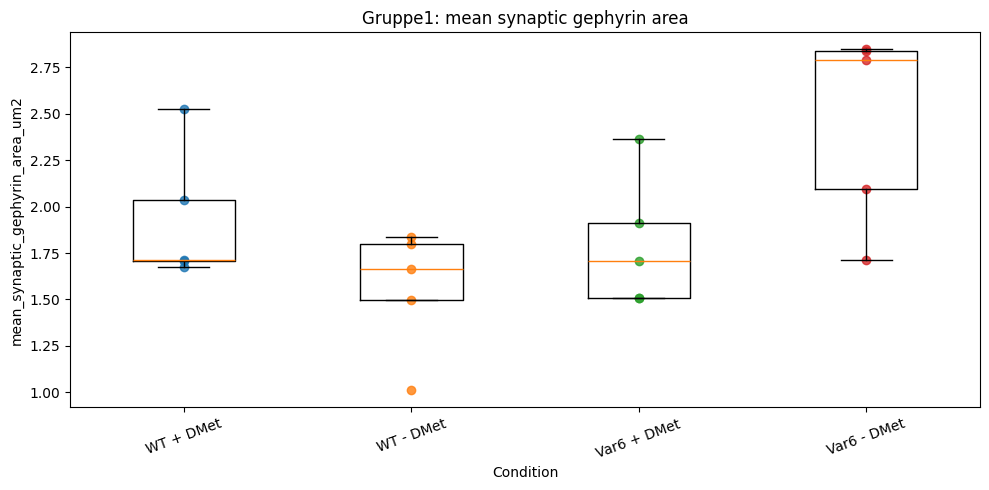

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\3784489789.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


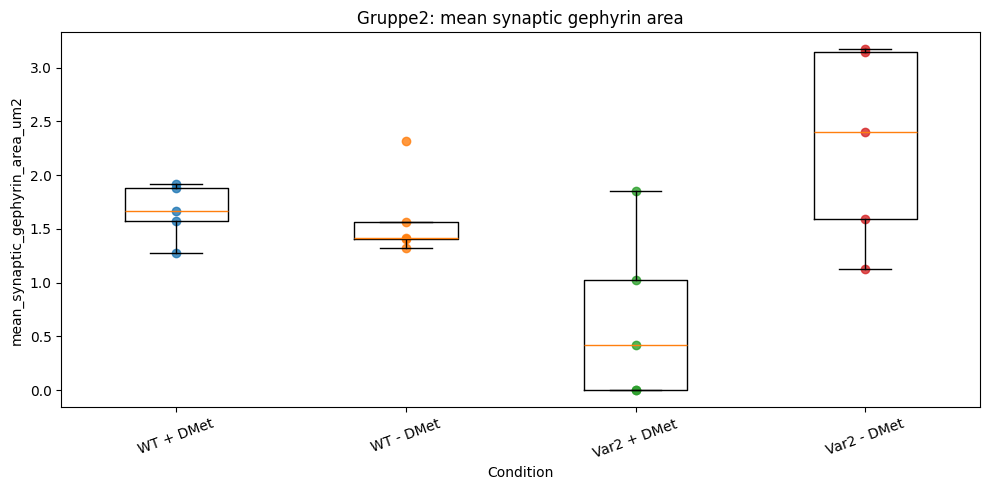

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\3784489789.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


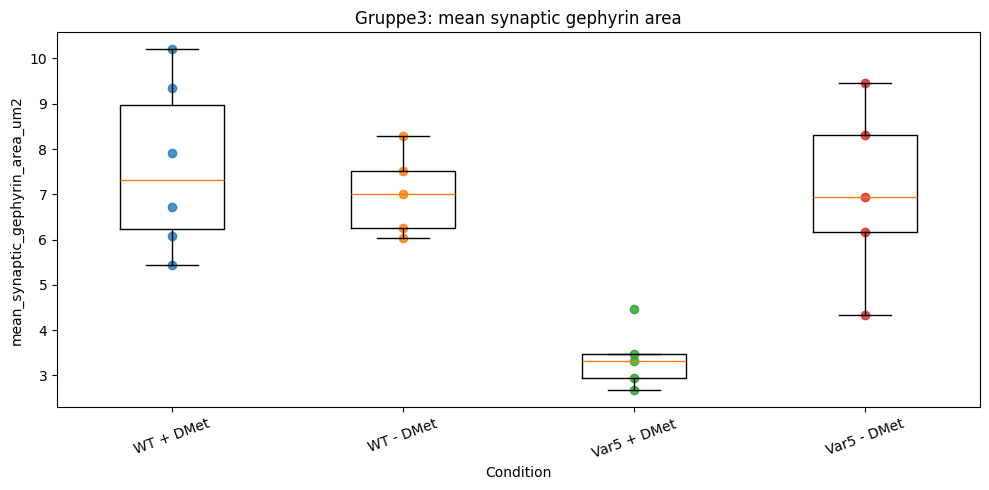

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\3784489789.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


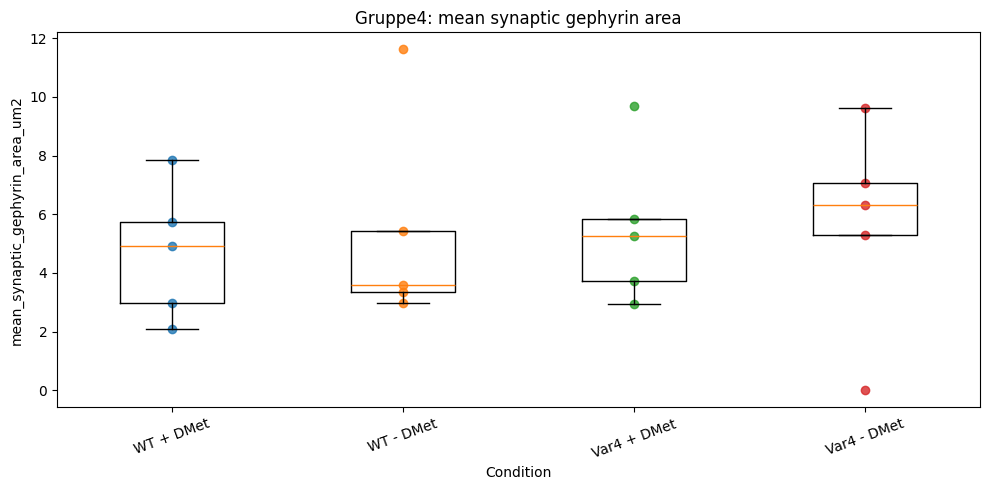

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\3784489789.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


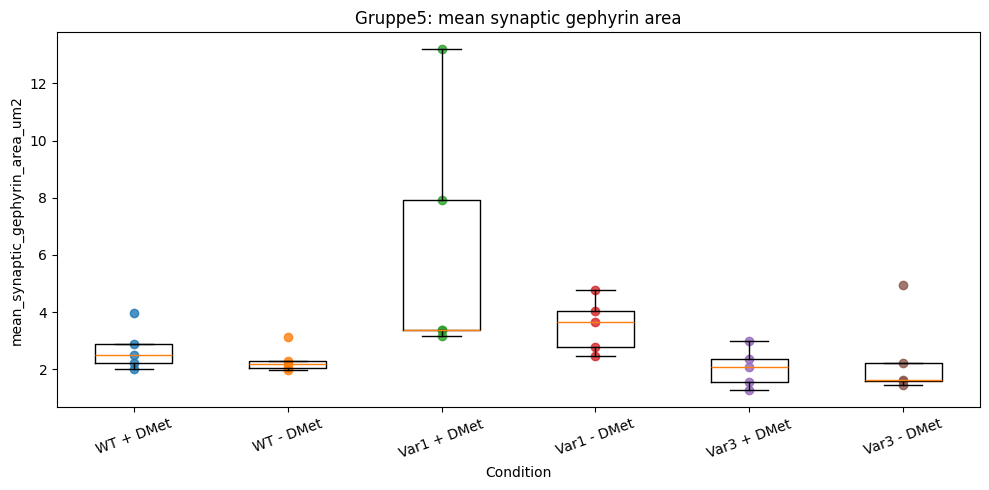

In [9]:
import re

plot_df = final_df.copy()

def read_group_and_condition(source_lif_name):
    text = str(source_lif_name).replace("_", " ")

    group_match = re.search(r"(?:Gruppe|Group)\s*(\d+)", text, flags=re.IGNORECASE)
    condition_match = re.search(r"(WT|Var\s*\d+)\s*([+-])\s*DMet", text, flags=re.IGNORECASE)

    if group_match is None or condition_match is None:
        return None, None

    group_name = f"Gruppe{group_match.group(1)}"

    base_name = condition_match.group(1).replace(" ", "")
    if base_name.upper() == "WT":
        base_name = "WT"
    else:
        variant_number = re.search(r"\d+", base_name).group()
        base_name = f"Var{variant_number}"

    sign = condition_match.group(2)
    condition_name = f"{base_name} {sign} DMet"

    return group_name, condition_name

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

def group_sort_key(group_name):
    return int(re.search(r"\d+", group_name).group())

def condition_sort_key(condition_name):
    if condition_name.startswith("WT"):
        base_order = 0
    else:
        base_order = int(re.search(r"\d+", condition_name).group())

    sign_order = 0 if "+" in condition_name else 1
    return (base_order, sign_order)

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    values_per_condition = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_area_um2"
        ].dropna()
        values_per_condition.append(values)

    plt.figure(figsize=(10, 5))
    plt.boxplot(values_per_condition, labels=conditions, showfliers=False)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_area_um2"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8)

    plt.title(f"{group_name}: mean synaptic gephyrin area")
    plt.xlabel("Condition")
    plt.ylabel("mean_synaptic_gephyrin_area_um2")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1361670235.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


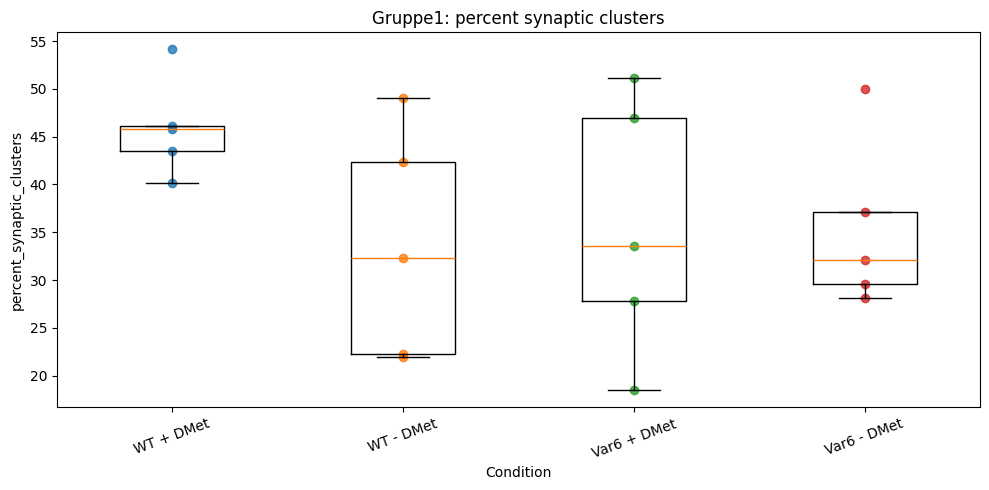

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1361670235.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


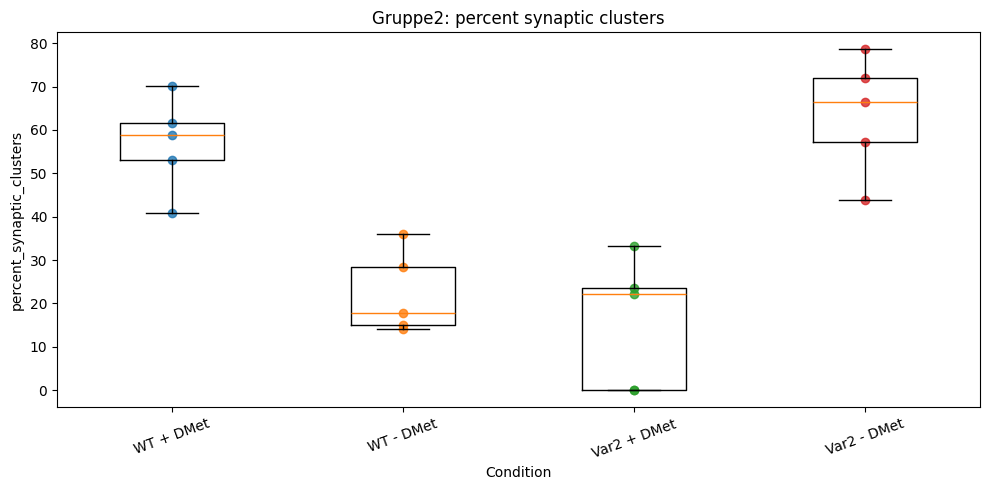

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1361670235.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


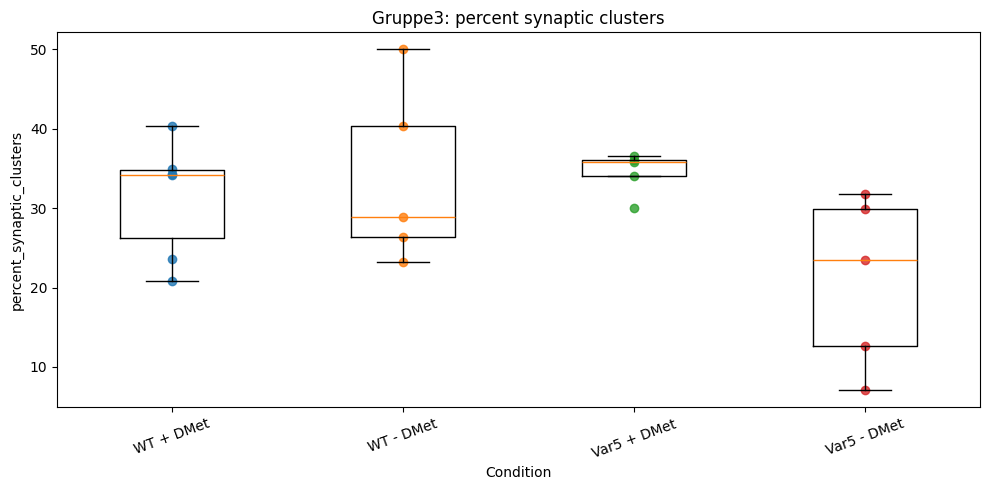

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1361670235.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


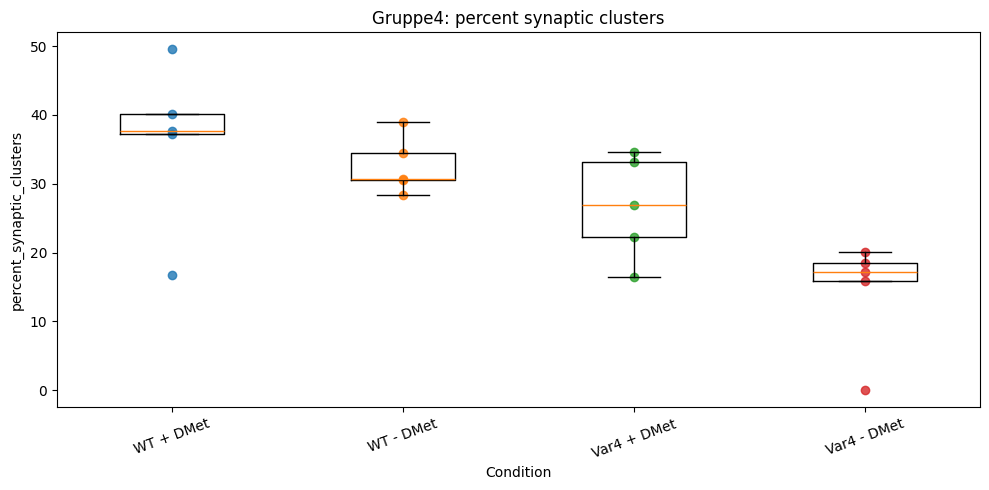

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1361670235.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


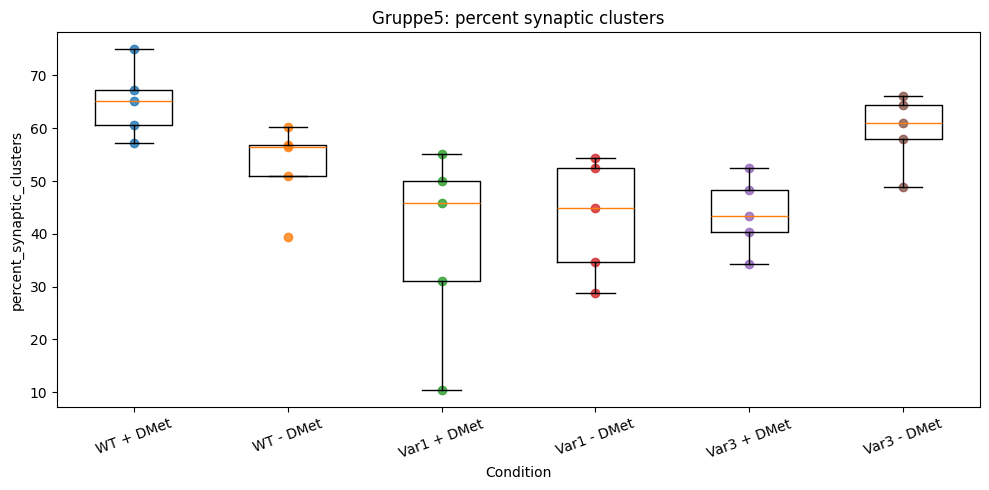

In [10]:
plot_df = final_df.copy()

plot_df["percent_synaptic_clusters"] = (
    plot_df["#_synaptic_gephyrin_clusters"]
    / plot_df["#_gephyrin_clusters"]
    * 100
)

plot_df.loc[plot_df["#_gephyrin_clusters"] == 0, "percent_synaptic_clusters"] = np.nan

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    values_per_condition = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "percent_synaptic_clusters"
        ].dropna()
        values_per_condition.append(values)

    plt.figure(figsize=(10, 5))
    plt.boxplot(values_per_condition, labels=conditions, showfliers=False)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "percent_synaptic_clusters"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8)

    plt.title(f"{group_name}: percent synaptic clusters")
    plt.xlabel("Condition")
    plt.ylabel("percent_synaptic_clusters")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\186200076.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


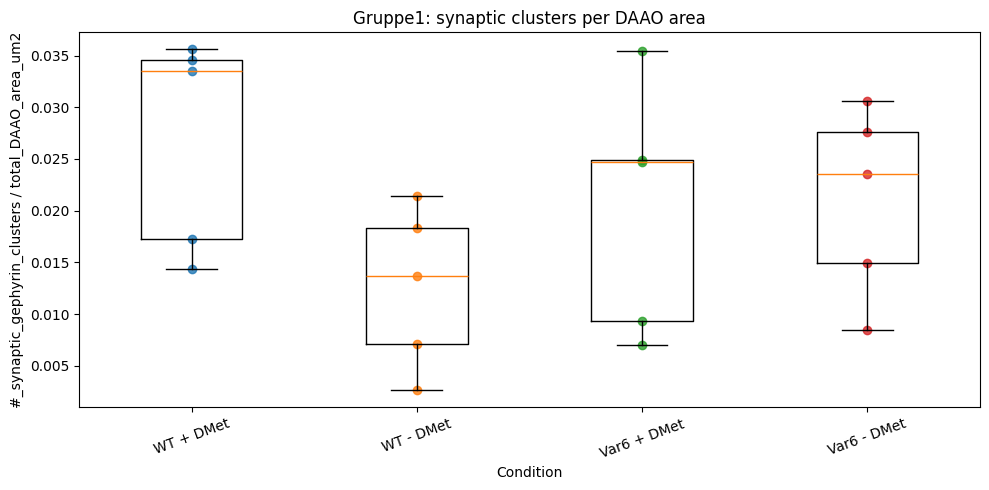

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\186200076.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


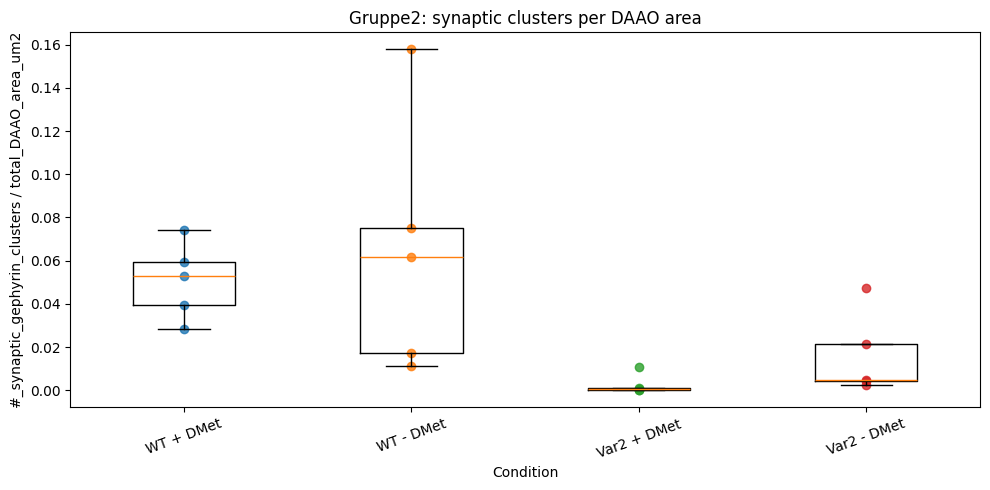

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\186200076.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


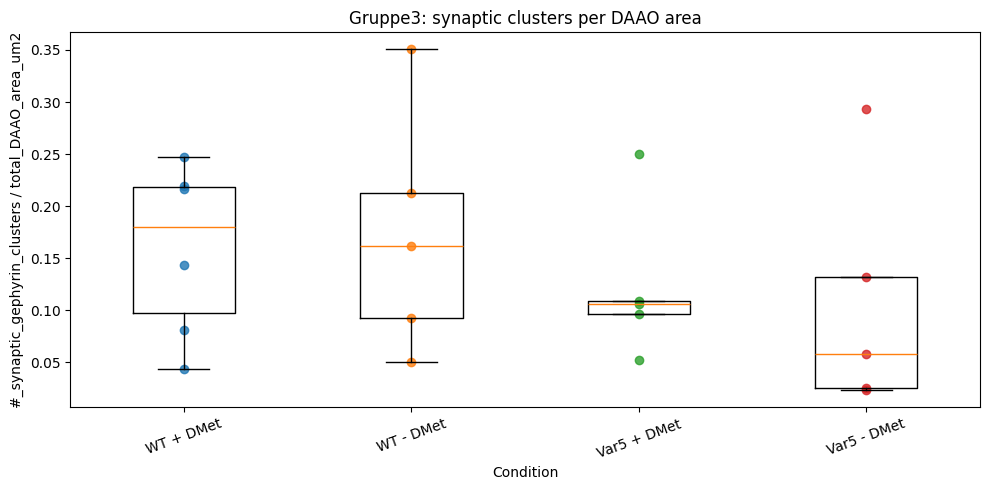

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\186200076.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


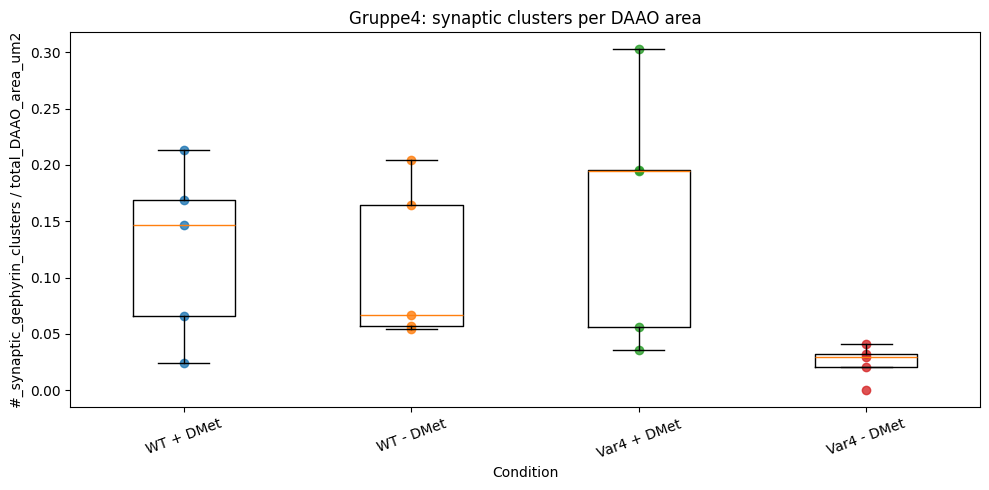

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\186200076.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


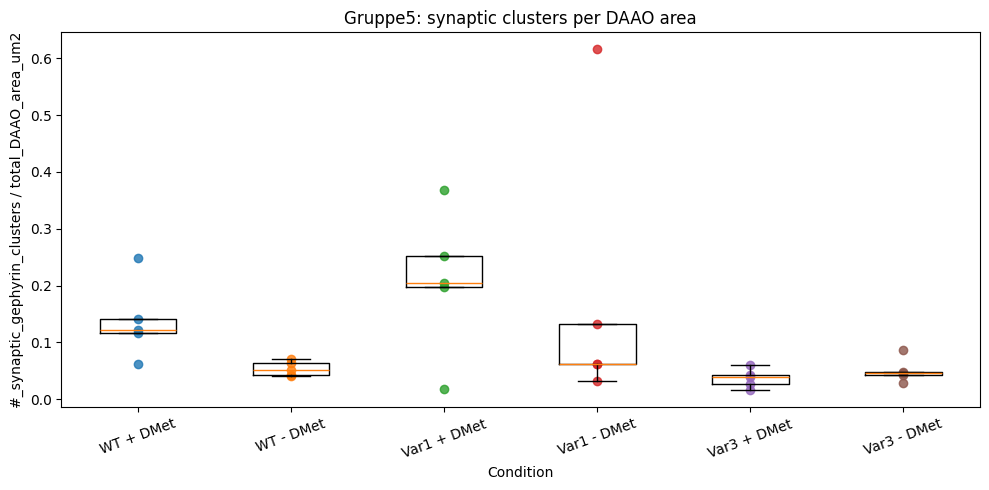

In [11]:
plot_df = final_df.copy()

plot_df["synaptic_clusters_per_DAAO_area"] = (
    plot_df["#_synaptic_gephyrin_clusters"]
    / plot_df["total_DAAO_area_um2"]
)

plot_df.loc[plot_df["total_DAAO_area_um2"] == 0, "synaptic_clusters_per_DAAO_area"] = np.nan

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    values_per_condition = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "synaptic_clusters_per_DAAO_area"
        ].dropna()
        values_per_condition.append(values)

    plt.figure(figsize=(10, 5))
    plt.boxplot(values_per_condition, labels=conditions, showfliers=False)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "synaptic_clusters_per_DAAO_area"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8)

    plt.title(f"{group_name}: synaptic clusters per DAAO area")
    plt.xlabel("Condition")
    plt.ylabel("#_synaptic_gephyrin_clusters / total_DAAO_area_um2")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1105962071.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


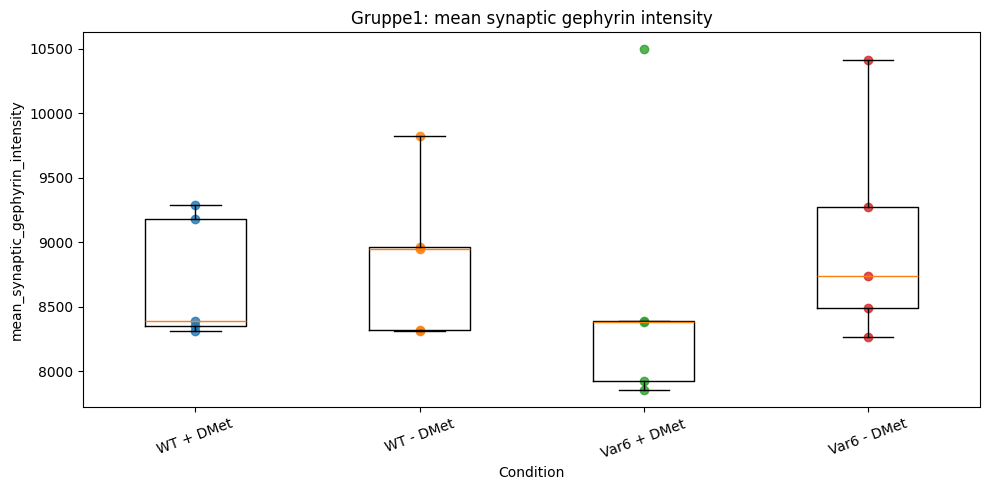

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1105962071.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


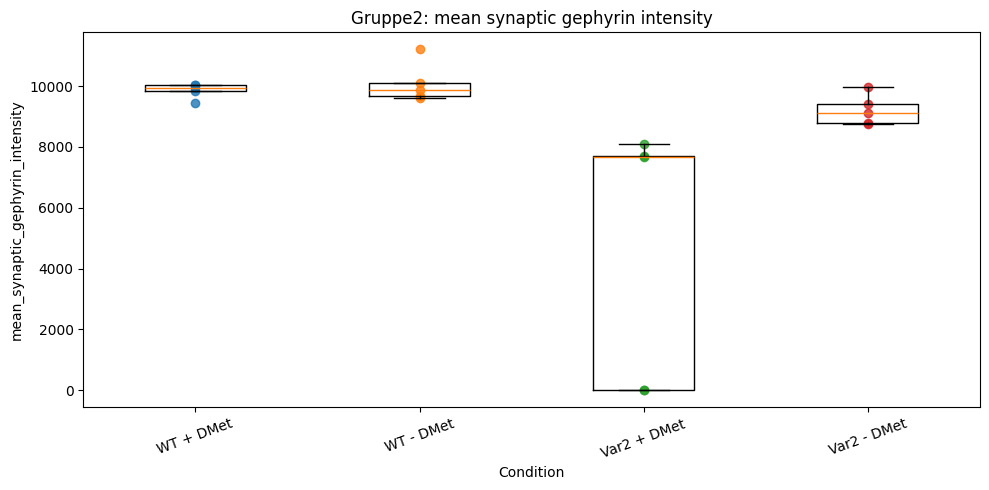

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1105962071.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


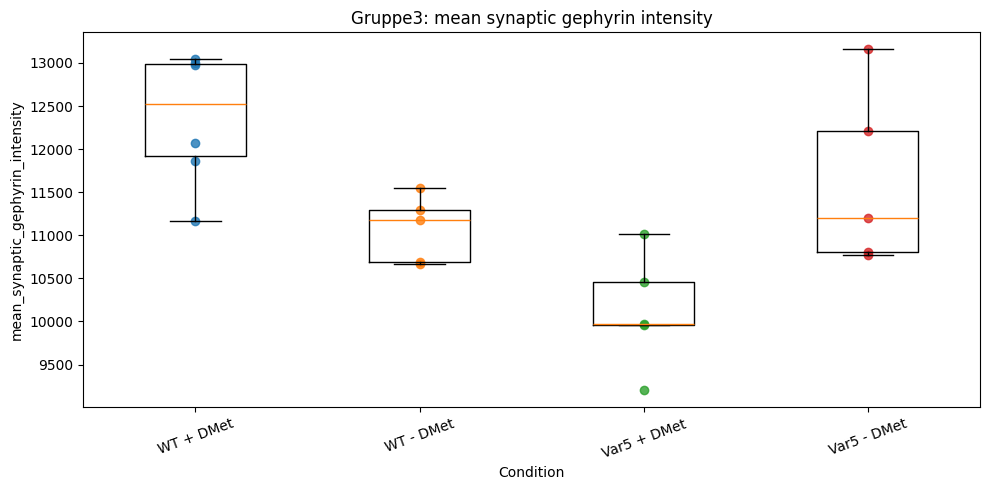

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1105962071.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


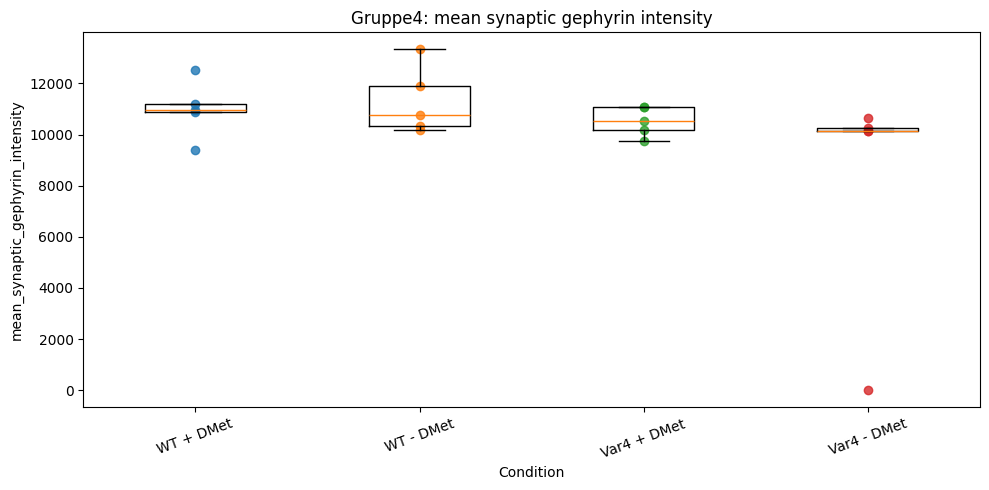

C:\Users\liebs\AppData\Local\Temp\ipykernel_18584\1105962071.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values_per_condition, labels=conditions, showfliers=False)


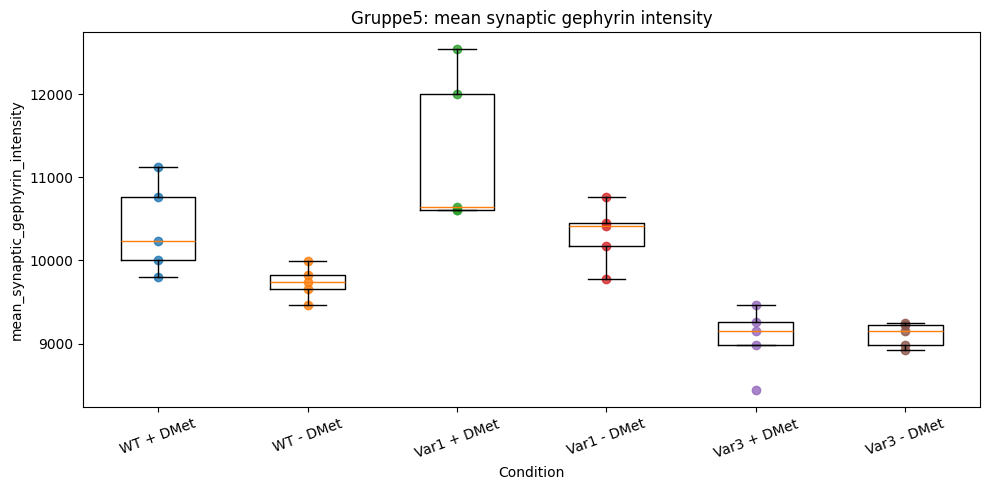

In [12]:
plot_df = final_df.copy()

parsed_values = plot_df["source_lif"].apply(read_group_and_condition)
plot_df["Gruppe"] = parsed_values.str[0]
plot_df["condition"] = parsed_values.str[1]

failed_rows = plot_df[plot_df["Gruppe"].isna() | plot_df["condition"].isna()]
if not failed_rows.empty:
    print("These source_lif values could not be parsed:")
    display(failed_rows[["source_lif"]].drop_duplicates())

plot_df = plot_df.dropna(subset=["Gruppe", "condition"]).copy()

all_groups = sorted(plot_df["Gruppe"].unique(), key=group_sort_key)

for group_name in all_groups:
    group_df = plot_df[plot_df["Gruppe"] == group_name].copy()
    conditions = sorted(group_df["condition"].unique(), key=condition_sort_key)

    values_per_condition = []
    for condition_name in conditions:
        values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_intensity"
        ].dropna()
        values_per_condition.append(values)

    plt.figure(figsize=(10, 5))
    plt.boxplot(values_per_condition, labels=conditions, showfliers=False)

    for position, condition_name in enumerate(conditions, start=1):
        y_values = group_df.loc[
            group_df["condition"] == condition_name,
            "mean_synaptic_gephyrin_intensity"
        ].dropna().to_numpy()
        x_values = [position] * len(y_values)
        plt.scatter(x_values, y_values, alpha=0.8)

    plt.title(f"{group_name}: mean synaptic gephyrin intensity")
    plt.xlabel("Condition")
    plt.ylabel("mean_synaptic_gephyrin_intensity")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()